### Analisis de procesamiento de señales - UNSAM <img src=./logo_UNSAM.jpg align=right width=150>
## TS0 : Implementación de función seno
### Lanzavechia, Jeronimo

*En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:*

- *la amplitud máxima de la senoidal (volts)*
- *su valor medio (volts)*
- *la frecuencia (Hz)*
- *la fase (radianes)*
- *la cantidad de muestras digitalizada por el ADC (# muestras)*
- *la frecuencia de muestreo del ADC.*


## Implementacion Seno

Para una frecuencia de muestreo de 1000Hz y 1000 muestras, la funcion mi_funcion_seno toma las variables de entrada junto con funciones de la libreria numpy, para luego crear y devolver un vector para los pasos de tiempo y sus amplitudes correspondientes.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as ss

fs = 1000#Hz
N = 1000#muestras

def mi_funcion_seno(vmax, dc, ff, ph, nn, fs):
    
    """
    Variables de entrada
    vmax = Amplitud
    dc = componente de continua
    ff = frecuencia de señal
    ph = desplazamiento de fase
    nn = numero de muestras
    fs = frecuencia de muestreo
    Salida
    dt, amplitud a dt 
    """
    
    tt =  np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)
    return tt, xx

*la función que uds armen debería admitir se llamada de la siguiente manera*

*tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)*

## Grafico a 1Hz

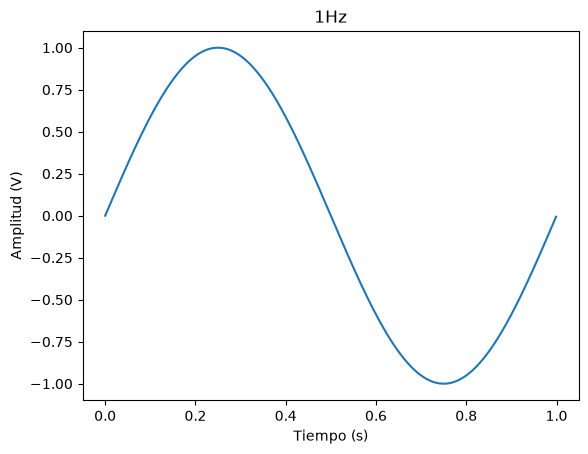

In [13]:
x,y = mi_funcion_seno(vmax = 1, dc = 0, ff = 1, ph = 0, nn = N, fs = fs)
plt.figure(1)
plt.title("1Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.plot(x,y)

## Bonus

*💎 Ser el primero en subir un enlace a tu notebook en esta tarea*

*Realizar los experimentos que se comentaron en clase (fs = 1000 Hz, N = 1000 muestras). Siguiendo la notación de la función definida más arriba:*
- *ff = 500 Hz*
- *ff = 999 Hz*
- *ff = 1001 Hz*
- *ff = 2001 Hz*
*🤯 Implementar alguna otra señal propia de un generador de señales.*

## Implementacion

Llamo a la funcion de la misma forma, ahora con las frecuencias pedidas en el bonus:

### 500Hz

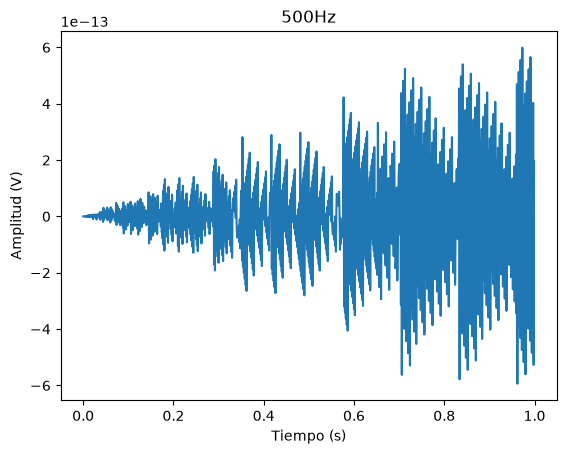

In [14]:
"""
Bonus: ff = 500Hz, 999Hz, 1001Hz, 2001Hz
"""

x,y = mi_funcion_seno(vmax = 1, dc = 0, ff = 500, ph = 0, nn = N, fs = fs)
plt.figure(2)
plt.title("500Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.plot(x,y)


### 999Hz

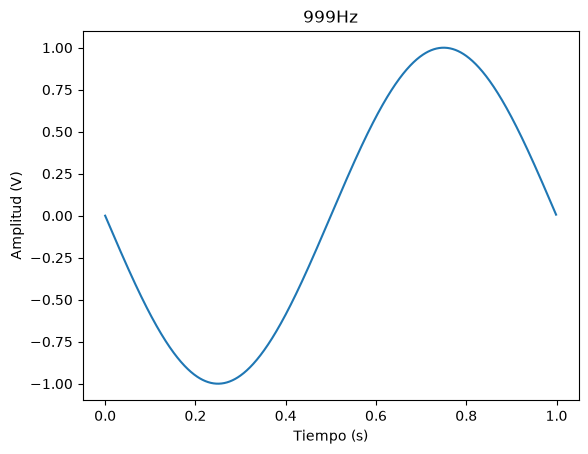

In [15]:
x,y = mi_funcion_seno(vmax = 1, dc = 0, ff = 999, ph = 0, nn = N, fs = fs)
plt.figure(3)
plt.title("999Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.plot(x,y)

### 1001Hz

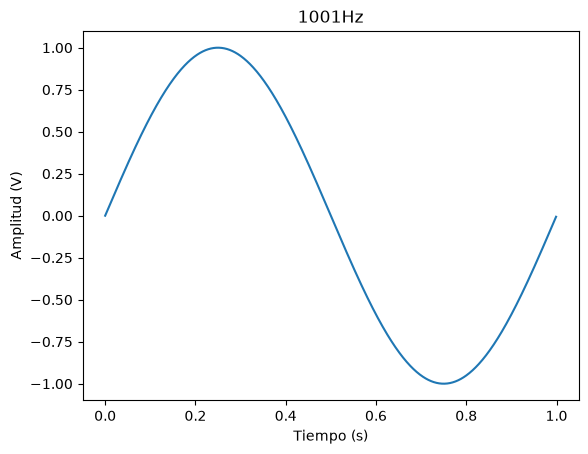

In [21]:
x,y = mi_funcion_seno(vmax = 1, dc = 0, ff = 1001, ph = 0, nn = N, fs = fs)
plt.figure(4)
plt.title("1001Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.plot(x,y)

### 2001Hz

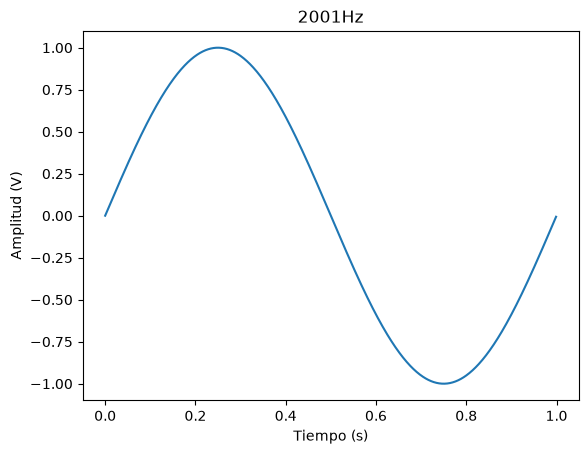

In [17]:
x,y = mi_funcion_seno(vmax = 1, dc = 0, ff = 2001, ph = 0, nn = N, fs = fs)
plt.figure(5)
plt.title("2001Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.plot(x,y)

## Implementacion Diente de Sierra

Una diente de sierra es una funcion que oscila entre 2 valores formando pendientes segun ya sea solo de subida, bajada o ambas segun su configuracion. Esta funcion deberia poder aceptar diferentes amplitudes, componentes de continua, frencuencias, desplazamiento de fase, y frecuencia de muestreo junto con la cantidad de muestras. Se utiliza la libreria scipy.signal para trabajar con la funcion sawtooth, y con ella realizar la implementacion:

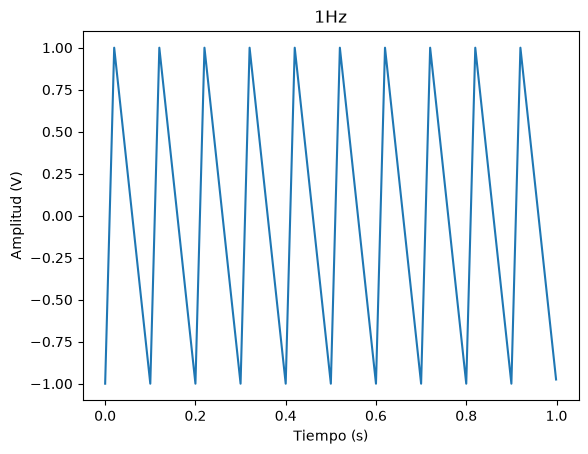

In [19]:
def mi_funcion_dienteDeSierra(vmax, dc, width, ff, nn, fs):
    """
    Variables de entrada
    vmax = Amplitud
    dc = componente de continua
    width = ancho de pendiente de subida
    ff = frecuencia de señal
    nn = numero de muestras
    fs = frecuencia de muestreo
    Salida
    dt, amplitud a dt 
    """
    tt =  np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * ss.sawtooth( 2*np.pi*tt*ff , width)
    return tt, xx


x,y = mi_funcion_dienteDeSierra(vmax = 1, dc = 0, width = 0.2, ff = 10, nn = N, fs = fs)
plt.figure(6)
plt.title("1Hz")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.plot(x,y)

## Conclusiones
### Senos de distintas frecuencias:
A medida que se cambia la frecuencia de la señal, la frecuencia de muestreo tiene menos tiempo para tomar muestras de los ciclos. acercandonos a los 500Hz, estamos a mitad de fs. Solo tomamos 2 muestras por ciclo. La forma de onda deberia ser una continua sobre los 0V, pero como np.pi no es π, se va desplazando de a poco el punto sobre t donde se realiza la muestra. En 1001Hz y 2001Hz, la frecuencia de muestreo es inferior, haciendo que se tome 1 solo punto por ciclo. No tenemos las muestras suficientes para construir la onda. La forma resultante depende de cuanto sea mayor nuestra frecuencia de oscilacion de la frecuencia de muestreo.